## Imports

In [2]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import EXP_neuro_fuzzy_toolbox as nft

## Data

In [3]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 7.0527e-01,  8.6075e-01, -6.1223e-01],
        [-3.5192e-01, -4.8823e-02, -9.1554e-01],
        [ 5.0850e-01, -4.5328e-01,  6.1148e-01],
        [-3.4129e-01,  7.1046e-03,  6.3888e-01],
        [-2.8024e-01, -5.3404e-01, -5.2135e-01],
        [ 3.3282e-01,  6.7854e-01, -2.3162e-01],
        [ 5.5757e-01,  9.6541e-01,  5.5212e-01],
        [-1.8722e-01,  4.8261e-01,  2.3724e-01],
        [-6.6685e-01,  8.5342e-03, -8.1782e-01],
        [-5.0106e-01,  2.5668e-01, -7.1968e-01],
        [-6.3341e-02,  3.2756e-01,  9.4571e-01],
        [-8.8780e-01, -7.8161e-01, -1.0555e-01],
        [ 1.4975e-01,  4.4424e-01, -5.8780e-01],
        [ 5.1611e-01, -8.9975e-01, -6.1014e-01],
        [-5.3546e-01, -1.6403e-01,  9.7814e-01],
        [ 8.6379e-01, -4.7647e-01,  5.6022e-01],
        [ 1.9053e-01,  2.1644e-01,  3.0228e-01],
        [-6.5196e-01, -3.4707e-01,  9.1917e-01],
        [-8.4088e-01,  9.3260e-01,  7.3288e-01],
        [ 5.5058e-01, -5.7248e-01,  6.1538e-01],
        [-5.3748e-01

In [4]:
y_train = torch.rand(200)
y_train

tensor([0.3344, 0.7805, 0.7144, 0.3497, 0.3035, 0.3851, 0.8729, 0.8928, 0.0220,
        0.0383, 0.6769, 0.9155, 0.1662, 0.0456, 0.4574, 0.1417, 0.9466, 0.8292,
        0.3204, 0.2076, 0.2860, 0.8717, 0.7467, 0.6187, 0.1181, 0.1604, 0.5076,
        0.5145, 0.6337, 0.1286, 0.8642, 0.2921, 0.7565, 0.9423, 0.2166, 0.7399,
        0.1968, 0.4816, 0.9369, 0.6248, 0.6374, 0.9569, 0.0984, 0.4775, 0.5032,
        0.6492, 0.8624, 0.9108, 0.5841, 0.5030, 0.3763, 0.8809, 0.7406, 0.4939,
        0.5709, 0.6027, 0.1016, 0.6356, 0.5812, 0.3212, 0.9240, 0.9071, 0.5203,
        0.6400, 0.3930, 0.4985, 0.6218, 0.2895, 0.3007, 0.4181, 0.1184, 0.4603,
        0.5515, 0.6343, 0.7949, 0.7546, 0.5012, 0.4364, 0.2846, 0.7031, 0.1092,
        0.4408, 0.9429, 0.1835, 0.9050, 0.0439, 0.7889, 0.0373, 0.8697, 0.5979,
        0.8279, 0.9342, 0.5034, 0.6599, 0.7627, 0.0417, 0.9187, 0.5284, 0.1652,
        0.6848, 0.5657, 0.7335, 0.5317, 0.3767, 0.4228, 0.7392, 0.0586, 0.3793,
        0.0699, 0.8371, 0.8573, 0.5710, 

## Model

In [5]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

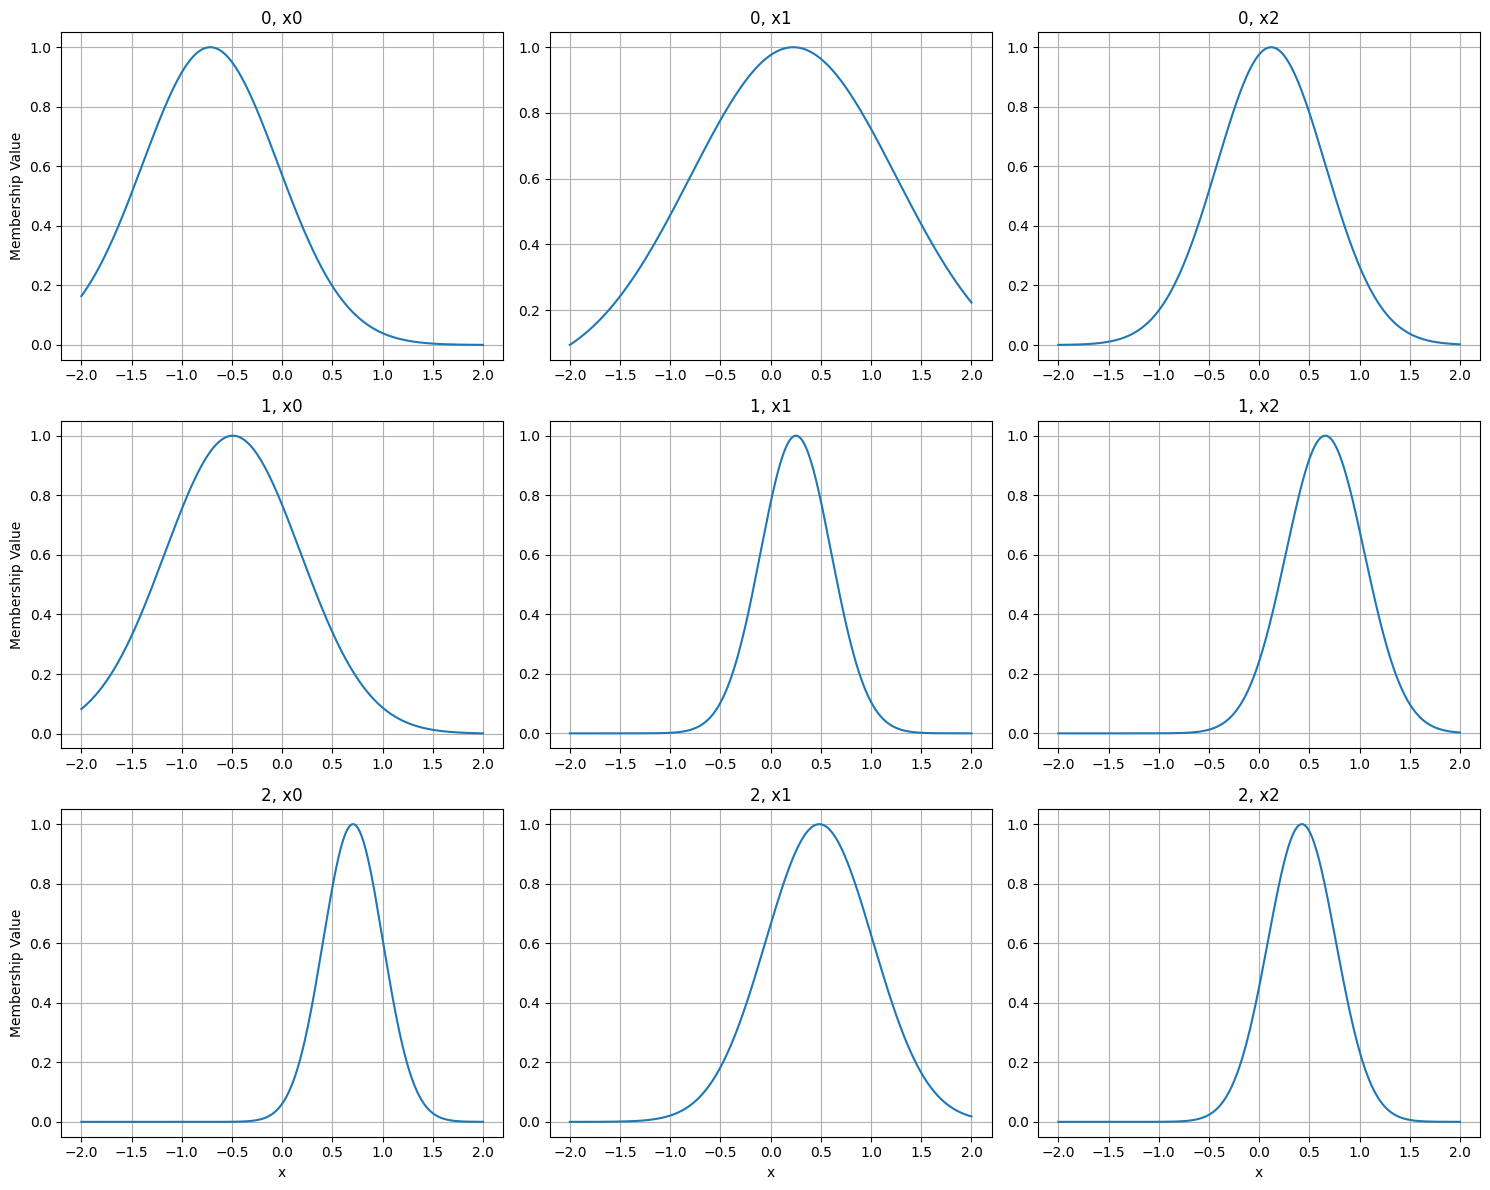

In [6]:
model.plot_premises()

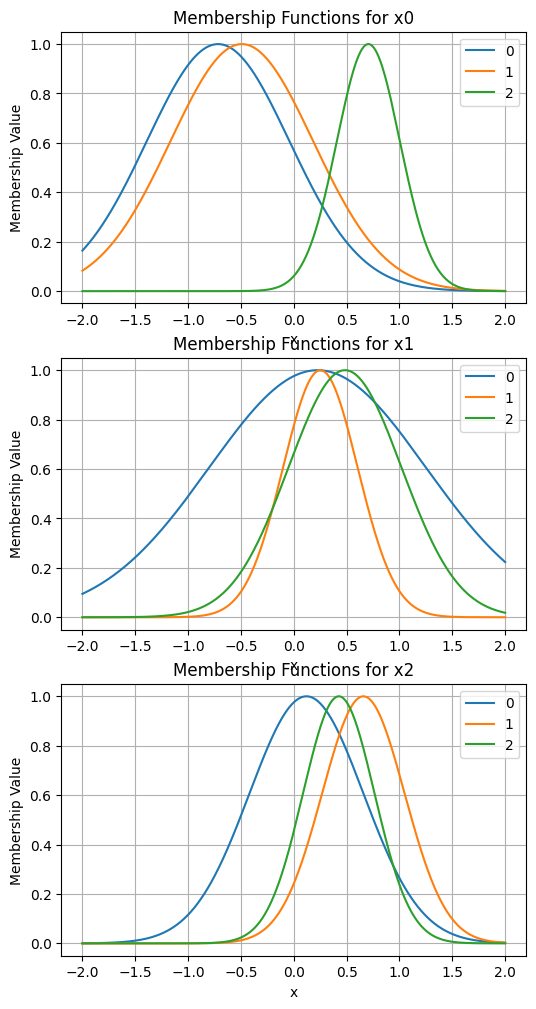

In [7]:
model.plot_premises(group_by_dim=True)

In [8]:
model.init_premises(x_train)

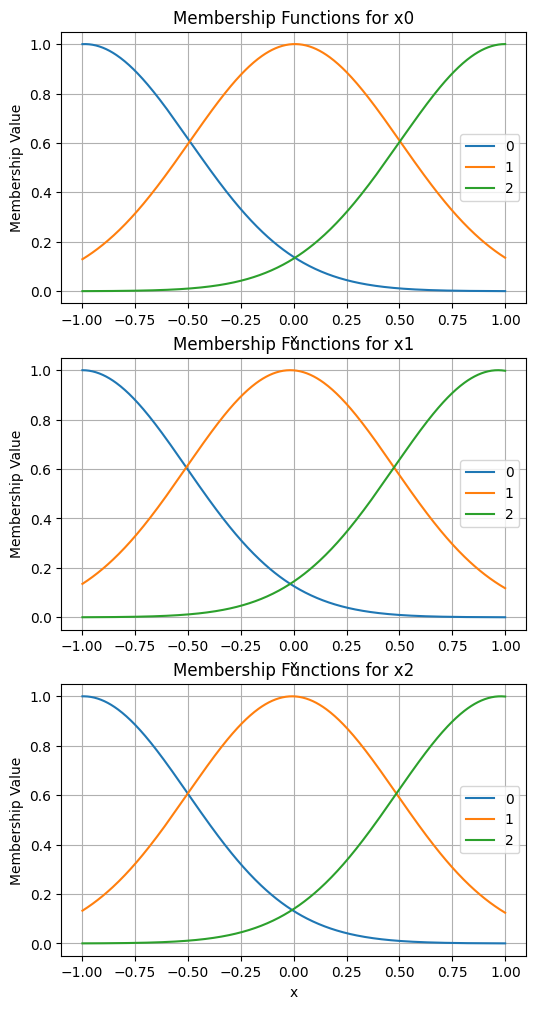

In [9]:
model.plot_premises(group_by_dim=True)

In [11]:
model.get_premises_structure()

x0                  x1                  x2          
         mu     sigma        mu     sigma        mu     sigma
0 -0.986123  0.496302 -0.997184  0.490649 -0.991980  0.492529
1  0.006482  0.496302 -0.015886  0.490649 -0.006921  0.492529
2  0.999087  0.496302  0.965411  0.490649  0.978138  0.492529

In [13]:
model.get_premises()

tensor([[[-0.9861,  0.4963],
         [ 0.0065,  0.4963],
         [ 0.9991,  0.4963]],

        [[-0.9972,  0.4906],
         [-0.0159,  0.4906],
         [ 0.9654,  0.4906]],

        [[-0.9920,  0.4925],
         [-0.0069,  0.4925],
         [ 0.9781,  0.4925]]])

In [15]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.872120,-0.815300,-0.740828,-0.934456
rule 2,0.015712,-0.389963,0.406645,-0.123829
rule 3,0.141968,0.341634,0.292499,-0.926600
rule 4,0.271520,-0.058224,-0.564114,0.460142
rule 5,0.327786,-0.097749,-0.212043,0.281236
rule 6,0.075244,-0.017019,0.688970,0.529830
rule 7,-0.480179,-0.314081,0.336038,0.611877
rule 8,0.449060,-0.693789,-0.339831,0.495448
rule 9,-0.450394,-0.278882,0.557099,-0.775639


In [16]:
model.init_consequents(x_train, y_train)

In [18]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-22.853462,-15.473166,10.870131,-23.263865
rule 2,-4.953736,8.256139,16.812546,4.054664
rule 3,15.223582,-35.113331,24.512981,-40.492809
rule 4,9.734504,-8.276407,-14.956734,-4.010637
rule 5,9.637137,-6.561929,-18.772060,4.316764
rule 6,-29.489386,-18.086836,-14.901860,-6.973665
rule 7,-30.046581,5.377233,15.817700,-14.772386
rule 8,-14.043553,-15.160341,4.974732,-2.391415
rule 9,15.074963,-10.143417,-11.221434,35.678532


In [22]:
model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1  -0.986123  0.496302 -0.997184  0.490649 -0.991980  0.492529   
rule 2  -0.986123  0.496302 -0.997184  0.490649 -0.006921  0.492529   
rule 3  -0.986123  0.496302 -0.997184  0.490649  0.978138  0.492529   
rule 4  -0.986123  0.496302 -0.015886  0.490649 -0.991980  0.492529   
rule 5  -0.986123  0.496302 -0.015886  0.490649 -0.006921  0.492529   
rule 6  -0.986123  0.496302 -0.015886  0.490649  0.978138  0.492529   
rule 7  -0.986123  0.496302  0.965411  0.490649 -0.991980  0.492529   
rule 8  -0.986123  0.496302  0.965411  0.490649 -0.006921  0.492529   
rule 9  -0.986123  0.496302  0.965411  0.490649  0.978138  0.492529   
rule 10  0.006482  0.496302 -0.997184  0.490649 -0.991980  0.492529   
rule 11  0.006482  0.496302 -0.997184  0.490649 -0.006921  0.492529   
rule 12  0.006482  0.496302 -0.997184  0.490649  0.978138  0.492529   
rule 13  0.006482  0.496302 -0.015886  0.490649 -0.991980  0.492529   
rule 14  0.006482  0.496302 -0.015886  0.490649 -0.006921  0.492529   
rule 15  0.006482  0.496302 -0.015886  0.490649  0.978138  0.492529   
rule 16  0.006482  0.496302  0.965411  0.490649 -0.991980  0.492529   
rule 17  0.006482  0.496302  0.965411  0.490649 -0.006921  0.492529   
rule 18  0.006482  0.496302  0.965411  0.490649  0.978138  0.492529   
rule 19  0.999087  0.496302 -0.997184  0.490649 -0.991980  0.492529   
rule 20  0.999087  0.496302 -0.997184  0.490649 -0.006921  0.492529   
rule 21  0.999087  0.496302 -0.997184  0.490649  0.978138  0.492529   
rule 22  0.999087  0.496302 -0.015886  0.490649 -0.991980  0.492529   
rule 23  0.999087  0.496302 -0.015886  0.490649 -0.006921  0.492529   
rule 24  0.999087  0.496302 -0.015886  0.490649  0.978138  0.492529   
rule 25  0.999087  0.496302  0.965411  0.490649 -0.991980  0.492529   
rule 26  0.999087  0.496302  0.965411  0.490649 -0.006921  0.492529   
rule 27  0.999087  0.496302  0.965411  0.490649  0.978138  0.492529   

        output 1 consequents                                   
                          x0         x1         x2             
                          c0         c1         c2         c3  
rule 1            -22.853462 -15.473166  10.870131 -23.263865  
rule 2             -4.953736   8.256139  16.812546   4.054664  
rule 3             15.223582 -35.113331  24.512981 -40.492809  
rule 4              9.734504  -8.276407 -14.956734  -4.010637  
rule 5              9.637137  -6.561929 -18.772060   4.316764  
rule 6            -29.489386 -18.086836 -14.901860  -6.973665  
rule 7            -30.046581   5.377233  15.817700 -14.772386  
rule 8            -14.043553 -15.160341   4.974732  -2.391415  
rule 9             15.074963 -10.143417 -11.221434  35.678532  
rule 10           -14.875637  -0.176885  -9.330145 -10.256539  
rule 11             2.424219  -6.000424 -19.621107  -4.766250  
rule 12            11.649784  14.970974 -27.220816  40.041027  
rule 13            10.644002   1.174393   2.663408   5.158942  
rule 14             0.714184   0.119086  11.647758   3.022739  
rule 15           -21.082989   7.552290  15.086444 -15.465015  
rule 16           -25.168287  -2.532541 -14.004259 -12.676606  
rule 17           -10.755535   7.388299 -16.223658  -5.886977  
rule 18            16.914553  -0.569183 -18.232819  19.151230  
rule 19           -17.020842 -14.610541  -4.842508  -5.476573  
rule 20            11.112182   5.510257  -0.561065  -4.268482  
rule 21             8.342904 -35.353954  -1.204409 -41.696083  
rule 22            14.003269 -25.179327   2.786856 -14.150313  
rule 23            -2.389526   0.934052  -5.618041  -0.358527  
rule 24           -18.946861 -17.930592  -5.478066  32.006847  
rule 25           -24.841955 -24.808176  -6.689990  46.485165  
rule 26           -10.260516  -9.983060  -3.209851  19.348751  
rule 27            21.

In [23]:
model(x_train[:10])

tensor([0.2400, 0.6245, 0.4837, 0.6071, 0.3631, 0.4747, 0.9195, 0.6341, 0.4134,
        0.2443], grad_fn=<SqueezeBackward1>)

In [24]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.2400, 0.6245, 0.4837, 0.6071, 0.3631, 0.4747, 0.9195, 0.6341, 0.4134,
        0.2443])


In [25]:
model.predict(x_train[:10])

array([0.23995781, 0.6245011 , 0.48365736, 0.6070645 , 0.3631395 ,
       0.47472572, 0.91946757, 0.63409495, 0.41340065, 0.24432254],
      dtype=float32)

## Binary output

In [26]:
x_train = 2 * torch.rand(200, 3) - 1

In [27]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([1, 1, 0, 1, 0, 0, 0, 1, 1, 0])

In [28]:
bin_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: clasificación binaria
)

In [29]:
bin_model.predict(x_train[:10])

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [30]:
bin_model(x_train[:10])

tensor([0.5131, 0.5798, 0.5724, 0.6163, 0.5382, 0.5803, 0.5278, 0.5680, 0.5259,
        0.4952], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [31]:
x_train = 2 * torch.rand(200, 3) - 1

In [32]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([0, 0, 1, 1, 0, 0, 2, 2, 2, 1])

In [34]:
mul_class_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: clasificación multiclase
)

In [35]:
mul_class_model.predict(x_train[:10])

array([1, 3, 2, 1, 1, 1, 1, 2, 3, 2])

In [36]:
mul_class_model(x_train[:10])

tensor([[-0.1615,  0.1563, -0.0923,  0.0182],
        [ 0.0617, -0.4494,  0.5699,  0.5723],
        [-0.1091,  0.0968,  0.2498, -0.4896],
        [-0.1538, -0.0776, -0.2972, -0.3515],
        [-0.1435,  0.1896,  0.0196, -0.2007],
        [-0.1697,  0.1121, -0.0364, -0.1453],
        [-0.2980,  0.0868, -0.0111, -0.2027],
        [-0.2318, -0.0046,  0.0017, -0.1850],
        [-0.1833, -0.0174, -0.1425,  0.3877],
        [-0.0808,  0.0688,  0.1852, -0.3233]], grad_fn=<SqueezeBackward1>)

In [37]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.2154, 0.2960, 0.2308, 0.2578],
        [0.2029, 0.1217, 0.3373, 0.3381],
        [0.2302, 0.2829, 0.3296, 0.1574],
        [0.2655, 0.2865, 0.2301, 0.2179],
        [0.2214, 0.3089, 0.2606, 0.2091],
        [0.2226, 0.2950, 0.2543, 0.2281],
        [0.2040, 0.2998, 0.2718, 0.2244],
        [0.2190, 0.2749, 0.2766, 0.2295],
        [0.2003, 0.2365, 0.2087, 0.3546],
        [0.2352, 0.2732, 0.3069, 0.1846]], grad_fn=<SoftmaxBackward0>)

In [39]:
mul_class_model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1  -0.689667  1.057564  0.345896  1.084379  0.009429  0.225944   
rule 2  -0.689667  1.057564  0.345896  1.084379  0.268104  1.060570   
rule 3  -0.689667  1.057564  0.345896  1.084379  0.908317  0.533583   
rule 4  -0.689667  1.057564 -0.389150  0.583688  0.009429  0.225944   
rule 5  -0.689667  1.057564 -0.389150  0.583688  0.268104  1.060570   
rule 6  -0.689667  1.057564 -0.389150  0.583688  0.908317  0.533583   
rule 7  -0.689667  1.057564  0.077378  0.346760  0.009429  0.225944   
rule 8  -0.689667  1.057564  0.077378  0.346760  0.268104  1.060570   
rule 9  -0.689667  1.057564  0.077378  0.346760  0.908317  0.533583   
rule 10 -0.166351  0.542495  0.345896  1.084379  0.009429  0.225944   
rule 11 -0.166351  0.542495  0.345896  1.084379  0.268104  1.060570   
rule 12 -0.166351  0.542495  0.345896  1.084379  0.908317  0.533583   
rule 13 -0.166351  0.542495 -0.389150  0.583688  0.009429  0.225944   
rule 14 -0.166351  0.542495 -0.389150  0.583688  0.268104  1.060570   
rule 15 -0.166351  0.542495 -0.389150  0.583688  0.908317  0.533583   
rule 16 -0.166351  0.542495  0.077378  0.346760  0.009429  0.225944   
rule 17 -0.166351  0.542495  0.077378  0.346760  0.268104  1.060570   
rule 18 -0.166351  0.542495  0.077378  0.346760  0.908317  0.533583   
rule 19  0.352656  0.822201  0.345896  1.084379  0.009429  0.225944   
rule 20  0.352656  0.822201  0.345896  1.084379  0.268104  1.060570   
rule 21  0.352656  0.822201  0.345896  1.084379  0.908317  0.533583   
rule 22  0.352656  0.822201 -0.389150  0.583688  0.009429  0.225944   
rule 23  0.352656  0.822201 -0.389150  0.583688  0.268104  1.060570   
rule 24  0.352656  0.822201 -0.389150  0.583688  0.908317  0.533583   
rule 25  0.352656  0.822201  0.077378  0.346760  0.009429  0.225944   
rule 26  0.352656  0.822201  0.077378  0.346760  0.268104  1.060570   
rule 27  0.352656  0.822201  0.077378  0.346760  0.908317  0.533583   

        output 1 consequents                                ...  \
                          x0        x1        x2            ...   
                          c0        c1        c2        c3  ...   
rule 1             -0.628060 -0.703835 -0.247349 -0.783465  ...   
rule 2              0.565924  0.619947  0.269152  0.491861  ...   
rule 3              0.815660  0.115308 -0.217015  0.856416  ...   
rule 4             -0.865696  0.644698  0.277928  0.326237  ...   
rule 5             -0.737627 -0.425688 -0.299466 -0.699309  ...   
rule 6              0.180534  0.151839  0.767213 -0.799173  ...   
rule 7              0.479036  0.214499 -0.300304  0.066626  ...   
rule 8             -0.818472 -0.666980  0.416731 -0.009513  ...   
rule 9              0.747239 -0.775959 -0.147918 -0.921558  ...   
rule 10            -0.555432  0.848579  0.605455  0.185861  ...   
rule 11            -0.322442 -0.519791 -0.371278 -0.258351  ...   
rule 12             0.390217  0.559714 -0.074266 -0.284084  ...   
rule 13            -0.300027  0.288422 -0.352457 -0.042882  ...   
rule 14             0.504748  0.859248 -0.364587 -0.795602  ...   
rule 15            -0.893778  0.744197 -0.513664  0.551565  ...   
rule 16            -0.036683 -0.935712 -0.509372 -0.577477  ...   
rule 17             0.772391  0.107013 -0.969607  0.421875  ...   
rule 18             0.493972  0.550088 -0.238542 -0.706438  ...   
rule 19             0.303493  0.616379  0.042863 -0.034463  ...   
rule 20            -0.636001 -0.689900  0.566649 -0.399805  ...   
rule 21             0.644986 -0.155679  0.879468  0.466572  ...   
rule 22            -0.716978  0.297701  0.354197 -0.008218  ...   
rule 23            -0.379290 -0.293711 -0.676764  0.125907  ...   
rule 24            -0.902184  0.061954  0.015898  0.073198  ...   
rule 25            -0.049765 -0.030776 -0.098445 -0.406526  ...   
ru

## Multiple outputs

In [43]:
x_train = 2 * torch.rand(200, 2) - 1

In [44]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: regresión
)

In [46]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1 -0.306235  0.514952 -0.162959
 rule 2  0.275620 -0.184189  0.965339
 rule 3  0.062747 -0.499678 -0.323858
 rule 4 -0.830645  0.023497 -0.841139
 rule 5 -0.207072  0.441692  0.569544
 rule 6  0.099960 -0.685254  0.612195
 rule 7  0.690344 -0.970671 -0.120619
 rule 8  0.453228  0.023313  0.243416
 rule 9 -0.368927 -0.741266  0.680374,
               x0        x1          
               c0        c1        c2
 rule 1 -0.004030  0.665078 -0.035285
 rule 2  0.431076 -0.475494 -0.308950
 rule 3 -0.434011  0.985154  0.387979
 rule 4 -0.011415 -0.341645 -0.855237
 rule 5  0.587232  0.213293 -0.204586
 rule 6  0.850739 -0.654082  0.012803
 rule 7  0.839071  0.246883 -0.979292
 rule 8  0.926229  0.710988  0.748437
 rule 9 -0.816324 -0.739047 -0.309229]

In [47]:
model(x_train[:10])

tensor([[ 0.4168,  0.1514],
        [ 0.4247,  0.0760],
        [ 1.1203,  0.2937],
        [ 0.4050,  0.0622],
        [ 0.5337,  0.3174],
        [ 0.3468,  0.0251],
        [ 0.4153,  0.1361],
        [ 0.4056,  0.1277],
        [ 0.3990, -0.2982],
        [ 0.4101,  0.0766]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [49]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: clasificación multiclase
)

In [50]:
model(x_train[:10])

tensor([[-0.3088, -0.1212,  0.2358],
        [-0.4173,  0.4752,  0.1018],
        [-0.2036, -0.0989, -0.2679],
        [-0.2002, -0.2210, -0.2302],
        [-0.7847,  0.1708,  0.2395],
        [-0.1677, -0.0375,  0.5584],
        [-0.9628,  0.3332,  0.3402],
        [-0.6012,  0.0618, -0.0381],
        [-0.1880, -0.1783, -0.2781],
        [ 0.6558, -0.4552, -0.3401]], grad_fn=<SqueezeBackward1>)

In [51]:
model(x_train[:10], return_probabilities=True)

tensor([[0.2544, 0.3069, 0.4386],
        [0.1952, 0.4766, 0.3281],
        [0.3281, 0.3643, 0.3076],
        [0.3390, 0.3320, 0.3290],
        [0.1566, 0.4072, 0.4362],
        [0.2378, 0.2708, 0.4914],
        [0.1200, 0.4385, 0.4416],
        [0.2129, 0.4132, 0.3739],
        [0.3420, 0.3454, 0.3126],
        [0.5887, 0.1938, 0.2175]], grad_fn=<SoftmaxBackward0>)

In [52]:
model.predict(x_train[:10])

array([2, 1, 1, 0, 2, 2, 2, 1, 1, 0])

# Rule Reduced

In [53]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [55]:
rr_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
)

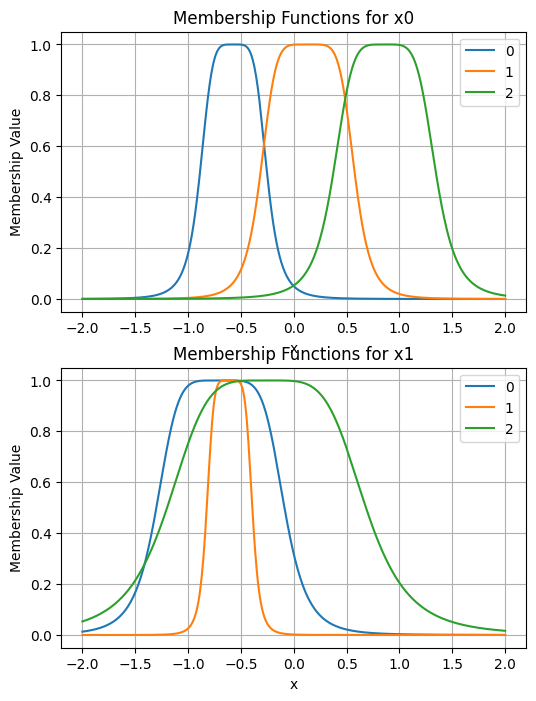

In [59]:
rr_model.plot_premises(group_by_dim=True)

In [62]:
rr_model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,-0.267712,0.296032,-0.931079
rule 2,0.048469,-0.268158,0.430475
rule 3,-0.193082,0.765454,0.861956


In [63]:
rr_model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.316324  2.487968 -0.570482  0.605987  2.814663 -0.694075   
rule 2  0.444351   2.91439  0.130515  0.215549  3.034417 -0.607876   
rule 3  0.483819  2.504578  0.859601  0.940998  2.337607 -0.257811   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1            -0.267712  0.296032 -0.931079  
rule 2             0.048469 -0.268158  0.430475  
rule 3            -0.193082  0.765454  0.861956